# Machine Learning Security Exercise 1
## Evasion Attacks on Machine Learning Models
## White-Box Attack with Fast Gradient Sign Method (FGSM)

In this notebook, we'll explore the concept of evasion attacks on machine learning models. 
Evasion attacks are a type of adversarial attack where an attacker manipulates input data so that a trained model makes incorrect predictions. This is particularly concerning 
in scenarios where machine learning models are used in security-critical applications, 
such as facial recognition, spam detection, or malware classification.


## 1. Simple Example: Binary Classification'
To begin, let's consider a simple example where we have a linear classifier trained on a binary classification task. 

### 1.1 Binary Classification via Logistic Regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification
from sklearn.metrics import log_loss


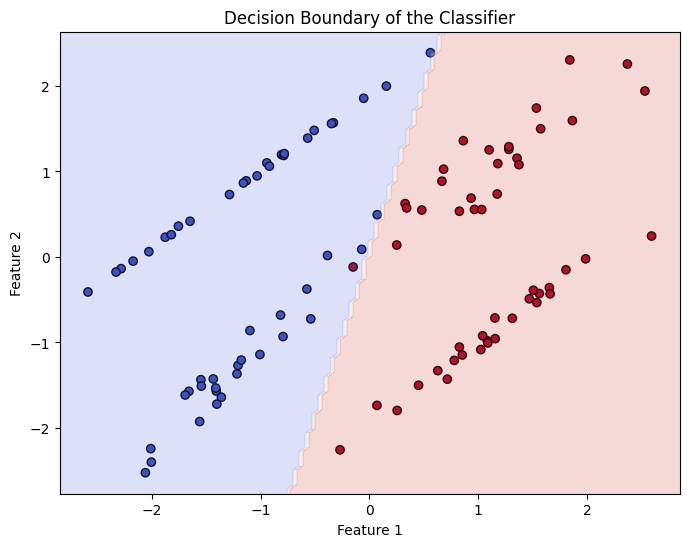

In [2]:
# Create a simple binary classification dataset with two features
X, y = make_classification(n_samples=100, n_classes=2,
                           n_features=2,
                           n_informative=2,  # Added for clarity
                           n_redundant=0,    # Added for clarity
                           random_state=42)

# Train a logistic regression model
model = LogisticRegression()
model.fit(X, y)


##### Plot the decision boundary ####
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()
xx, yy = np.meshgrid(np.linspace(xmin, xmax, 100), np.linspace(ymin, ymax, 100))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
plt.title('Decision Boundary of the Classifier')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

### 1.2 White-Box Evasion Attack

Let's say we have a data point that the model correctly classifies. We'll add a small perturbation to this point to cause the model to misclassify it.


Original Sample: [[0.55942643 2.38869353]]
Original Label: 0, Predicted Label: 0
Perturbed Sample: [[0.60942643 2.33869353]]
Perturbed Label: [1]


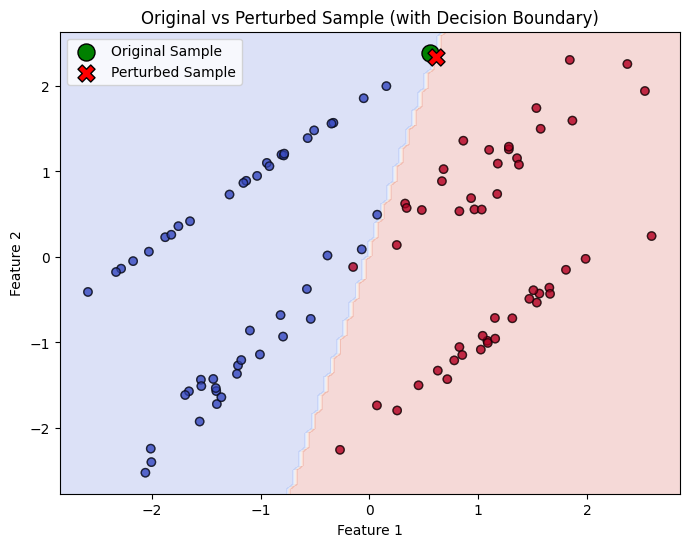

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss
# Assuming 'X', 'y', and 'model' are already defined and fitted

# Select a sample that is correctly classified
predictions_for_X = model.predict(X) # <-- This line was needed
correct_indices = np.where(predictions_for_X == y)[0]
sample_idx = correct_indices[0]
original_sample = X[sample_idx].reshape(1, -1)
original_label = y[sample_idx]
predicted_label = predictions_for_X[sample_idx] # <-- Use the correct variable

print(f"Original Sample: {original_sample}")
print(f"Original Label: {original_label}, Predicted Label: {predicted_label}")


# compute error and gradient
predicted_probabilities = model.predict_proba(original_sample)
loss = log_loss(y_true=[original_label],
                y_pred=predicted_probabilities,
                labels=model.classes_)

# 3. Compute the "Gradient (wrt to pixels/input)"
p_hat = predicted_probabilities[0, 1]
y_true = original_label
weights = model.coef_[0]
gradient_wrt_input = (p_hat - y_true) * weights

# Add a small perturbation to original sample
epsilon = 0.05
# Note: The sign is flipped for *adversarial* attack (to increase loss)
# For a simple perturbation, this is fine, but for an attack,
# you might want (p_hat - y_true) to be positive.
# Let's assume we are just pushing *away* from the correct label.
# A common FGSM-style update (to increase loss) would be:
# perturbed_sample = original_sample + epsilon * np.sign(gradient_wrt_input)
# But since your original label is likely 0, (p_hat - 0) is positive,
# and the gradient is positive. Adding to it pushes it *further* into
# class 1, which is correct.
# To make it flip, we should move *against* the gradient.
# Let's stick to your code for now:
perturbed_sample = original_sample + epsilon * np.sign(gradient_wrt_input)
perturbed_label = model.predict(perturbed_sample.reshape(1, -1))

print(f"Perturbed Sample: {perturbed_sample}")
print(f"Perturbed Label: {perturbed_label}")


##### Plot the original, perturbed samples, AND decision boundary #####
plt.figure(figsize=(8, 6))

# --- Plot Decision Boundary ---
# Plot all data points first to set the plot limits
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', alpha=0.6)

# Get plot limits
xmin, xmax = plt.xlim()
ymin, ymax = plt.ylim()

# Create meshgrid
xx, yy = np.meshgrid(np.linspace(xmin, xmax, 100), np.linspace(ymin, ymax, 100))
# Get model predictions on the grid
Z_boundary = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z_boundary = Z_boundary.reshape(xx.shape)

# Plot the decision boundary contour
plt.contourf(xx, yy, Z_boundary, alpha=0.2, cmap='coolwarm')
# --- End Decision Boundary ---

# Re-plot all points *on top* of the boundary for clarity
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', alpha=0.6)

# Plot the specific samples
plt.scatter(original_sample[0, 0], original_sample[0, 1],
            color='green', marker='o', s=150, # Made bigger
            edgecolors='k', label='Original Sample')
plt.scatter(perturbed_sample[0, 0], perturbed_sample[0, 1],
            color='red', marker='X', s=150, # Made bigger
            edgecolors='k', label='Perturbed Sample')

plt.legend()
plt.title('Original vs Perturbed Sample (with Decision Boundary)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

## 2.  Evasion Attack on ResNet Model Trained on ImageNet


Now that we've seen a simple example of an evasion attack, let's move on to a more complex scenario: attacking a ResNet model trained on the ImageNet dataset.

In [4]:
import torch
import os
print('Torch', torch.__version__, 'CUDA', torch.version.cuda)
print('Device:', torch.device('cuda:0'))
dev = None

if torch.cuda.is_available():
  dev = torch.device('cuda')
else:
  dev = torch.device("cpu")
print(f"Using device '{dev}'")


from PIL import Image
from torch.nn.functional import softmax
from torchvision import models, transforms, datasets
from torch import nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import numpy as np
import copy
import json
import requests


Torch 2.5.1 CUDA None
Device: cuda:0
Using device 'cpu'


In [5]:
def class_name_to_id(class_name):
    """
    Maps ImageNet class name to ID number between 0 and 1000 (exclusive)
    E.g. class_name_to_id('Border Collie') -> int
    """

    with open('imagenet-simple-labels.json', 'r') as f:
        class_names = json.load(f)

    for i, cn in enumerate(class_names):
        if cn == class_name:
            return i
    return None

def class_id_to_name(class_id):
    """
    Maps ImageNet class ID back to it's canonical class name
    """
    with open('imagenet-simple-labels.json', 'r') as f:
        class_names = json.load(f)
    return class_names[class_id]

def top_5_classes(y, class_names = None):
    """
    y : tensor([1, 1000])
    The output of the model, e.g. from running `model(to_tensor(x))`. The values
    are normalized in this function by using softmax to convert them to probabilities.
    """
    y = torch.Tensor.cpu(y)
    if class_names==None:
        with open('imagenet-simple-labels.json', 'r') as f:
            class_names = json.load(f)
    p = softmax(y[0,:], dim=0)
    values, indices = p.topk(5)
    return [(class_names[index], value) for index, value in zip(indices.detach().numpy(), values.detach().numpy())]
    
def probability_of_class(y, label):
    """
    If y is the output of a resnet model or similar, and label is an imagenet
    label, either the canonical name as a string, or an integer id, the model's
    confidence in classifying the output as `label` is returned.
    """
    y = torch.Tensor.cpu(y)
    if isinstance(label, str):
        label = class_name_to_id(label)
    if torch.is_tensor(label):
        label = int(torch.Tensor.cpu(label).detach().numpy())
    p = softmax(y[0,:], dim=0)
    return p[label].detach().numpy()

def autolabel(rects, ax, labels):
    """
    Auxiliary function to `plot_prediction`.

    Attach a text label above each bar displaying its height.
    See https://matplotlib.org/2.0.2/examples/api/barchart_demo.html
    """
    for rect, label in zip(rects, labels):
        height = rect.get_height()
        ax.text(rect.get_x() + rect.get_width()/2, 1.05*height, label, ha='left', va='bottom', rotation=45)
        
def plot_prediction(x, y, ax_img=None, ax_bar=None, title=None):
    """
    Visualises the input image along with the top 5 classifications of the model.

    Attributes
    ------------------
    x : PIL image
    The input image
    y : tensor([1, 1000])    
    The output of the model, e.g. from running `model(to_tensor(x))`
    """
    
    y = torch.Tensor.cpu(y)
    fig = None
    if ax_img is None or ax_bar is None:
        fig, axs = plt.subplots(ncols=2,figsize=(10,5))
    if title is not None:
        assert fig is not None
    fig.suptitle(title, fontsize=18)
    top_classes_str = ' '.join([f"{n} ({p:.3})" for n, p in top_5_classes(y)])
    title = f"Top classes: {top_classes_str}"
     
    axs[0].imshow(x)
    axs[0].axis('off')
    axs[0].set_title("Input image")
    ps = [p[1] for p in top_5_classes(y)]
    names = [p[0] for p in top_5_classes(y)]
    rects = axs[1].bar(np.arange(5), ps)
    if max(ps) > 0.9:
        axs[1].set_ylim([0.0, max(ps)+0.3])
    else:
        axs[1].set_ylim([0.0, max(ps)+0.1])
    autolabel(rects, axs[1], names)
    axs[1].set_title("Confidence for top 5 classes")


### 2.1 Load Pre-Trained weights of ResNet Model and add Transform Layer

In [6]:
resnet50 = models.resnet50(pretrained=False)
resnet50.load_state_dict(torch.load('resnet50-0676ba61.pth'))
resnet50 = resnet50.to(dev)
resnet50.eval()

/Users/tobias/PycharmProjects/ml_security/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/tobias/PycharmProjects/ml_security/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/var/folders/dq/dkcjrtrs1dd6v6mjw5240gxr0000gn/T/ipykernel_69304/78288972.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more d

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [7]:
# these operations are not autograd differentiable, so we apply them before feeding the input into the model
input_transform = transforms.Compose([transforms.Resize(256),
                                  transforms.CenterCrop(224), # 224 x 224
                                    ])
                         
class transform_layer(nn.Module):
    """
    Applies normalization according to https://pytorch.org/vision/0.8/models.html
    """
    def __init__(self):
        super(transform_layer, self).__init__()
        self.normalize_transform = transforms.Normalize(
                          mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]
                        )
        self.to_tensor = transforms.ToTensor()

    def forward(self, x):
    # apply the input_transform if it has not already been applied
        if not torch.is_tensor(x) and x.size != (224, 224):
            x = input_transform(x)
        # covert to tensor if not already done
        if not torch.is_tensor(x):
            x = self.to_tensor(x)

        x = x.to(dev)
        # then normalize
        x = self.normalize_transform(x)
        # add batch number
        if len(x.size()) == 3:
            return x.unsqueeze(0)
        else:
              return x

model = copy.deepcopy(resnet50)
# prepend the transformation
model = nn.Sequential(transform_layer(), model)


In [8]:
# transformations
to_tensor = transforms.ToTensor()
to_pil = transforms.ToPILImage()

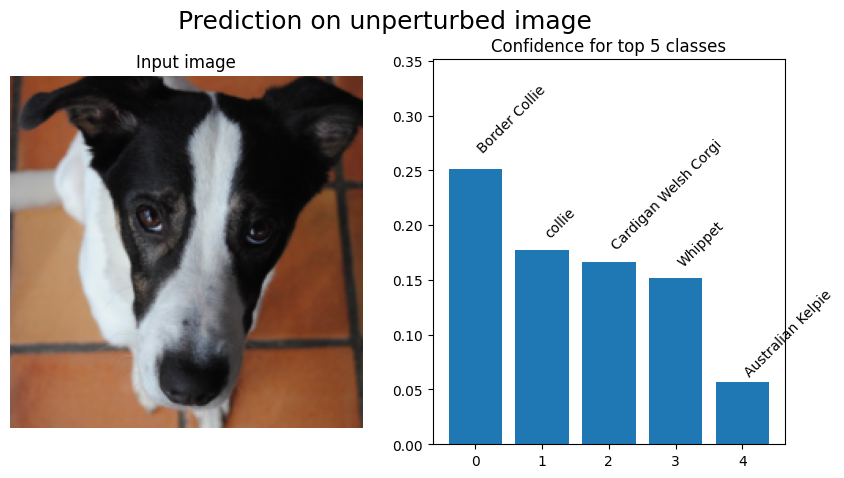

In [9]:
# Top 5 classes of Border Collie image
dog_img = Image.open("Border_Collie.jpg")
dog_img = input_transform(dog_img)
y = model(dog_img)
plot_prediction(dog_img, y, title="Prediction on unperturbed image")

### 2.2 Evasion Attack using FGSM
#### Part 1: Implementing the FGSM Perturbation Function
The first function you will implement is **`fgsm`**. This function perturbs an input image by adding a small amount of noise to the image, based on the sign of the gradient of the loss with respect to the input. 


#### Part 2: Implementing the FGSM Attack on an Image
In the second part, you will implement the **`fgsm_perturb_img`** function. This function will perform an FGSM attack on an input image using a trained neural network model and a given label by performing the forward pass through the model, computing the gradients and then using the function **`fgsm`** to generate the adversarial image. 




In [10]:

def fgsm(input_img, gradient, epsilon):
    """
    Adds perturbation on input image based on the gradient of the loss of the input image
    
    Attributes
    ------------------
    input_img : PIL image of image to be perturbed
    gradient: gradient of loss of input image
    epsilon: small constant that controls the size of perturbation added to the image
    
    Returns:
    -------------------
    (torch.tensor)
    A tensor representing the perturbed image with values clamped between 0 and 1, detached from the computational graph
    """

    perturbed_image = input_img + epsilon * torch.sign(gradient)
    return torch.clamp(perturbed_image, 0, 1).detach()

def fgsm_perturb_img(input_img, label, model, epsilon, loss_fct=nn.CrossEntropyLoss()):
    """
    Performs FGSM attack on provided input with amount epsilon.

    Arguments
    -------------------
    input : PIL.Image, input image of dimensions (224, 224)
    label : str, ImageNet class label name
    model : pytorch.nn.Module
    
    Returns
    -------------------
    (PIL.Image)
    The perturbed image after performing the FGSM attack
    """

    # --- Start of function body ---

    # 0. We need torchvision.transforms to convert between PIL and Tensors
    # (This code assumes 'import torchvision.transforms as transforms'
    # was run outside the function)

    # 1. Define pre-processing steps
    # 1a. Convert PIL image to a [0, 1] tensor
    to_tensor = transforms.ToTensor()

    # 1b. Normalize tensor for the ImageNet-trained model
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])

    # 1c. Define post-processing step (Tensor back to PIL)
    to_pil = transforms.ToPILImage()

    # 2. Get device, set model to evaluation mode
    device = next(model.parameters()).device
    model.eval()

    # 3. Process the input image
    # We need to keep the unnormalized [0, 1] tensor to apply the perturbation to
    img_tensor_0_1 = to_tensor(input_img).unsqueeze(0).to(device)

    # This is the normalized tensor that will go into the model
    input_tensor = normalize(img_tensor_0_1)

    # 4. Enable gradient tracking on the input
    input_tensor.requires_grad = True

    # 5. Forward pass
    output = model(input_tensor)

    # 6. Get the target tensor
    # Load the label mapping from the JSON file.
    # This list maps the index (class ID) to the string label.
    # Assumes 'imagenet-simple-labels.json' is in the working directory.
    try:
        with open('imagenet-simple-labels.json') as f:
            imagenet_labels = json.load(f)
    except FileNotFoundError:
        print("Error: 'imagenet-simple-labels.json' not found.")
        print("Please download it and place it in the same directory.")
        raise

    # Find the integer index corresponding to the string label
    try:
        label_index = imagenet_labels.index(label)
    except ValueError:
        # Handle case where the provided string label isn't in the list
        print(f"Error: Label '{label}' not found in imagenet-simple-labels.json")
        raise

    # Create the target tensor using the found index
    target = torch.tensor([label_index], dtype=torch.long).to(device)

    # 7. Calculate loss
    loss = loss_fct(output, target)

    # 8. Backward pass to get gradient
    model.zero_grad()
    loss.backward()

    # 9. Get the gradient of the loss with respect to the *input*
    gradient = input_tensor.grad.data

    # 10. Call the FGSM helper function
    # We apply the perturbation to the UNNORMALIZED [0, 1] image tensor
    # The fgsm function handles the math, clamping to [0, 1], and detaching
    perturbed_tensor_0_1 = fgsm(img_tensor_0_1, gradient, epsilon)

    # 11. Convert the perturbed [0, 1] tensor back to a PIL Image
    # .squeeze(0) removes the batch dimension
    # .cpu() moves data back to CPU for PIL conversion
    perturbed_pil = to_pil(perturbed_tensor_0_1.squeeze(0).cpu())

    return perturbed_pil
    

## 2.2 Perform FGSM on Border Bollie and African Bush Elephant 

Now choose an epsilon and generate an adversarial image for both given images using the implemented functions **`fgsm_perturb_img`** and   **`fgsm`**.

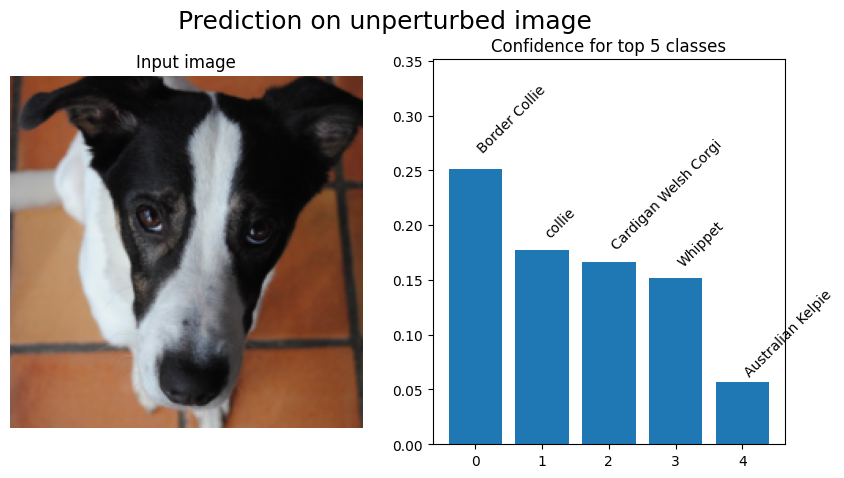

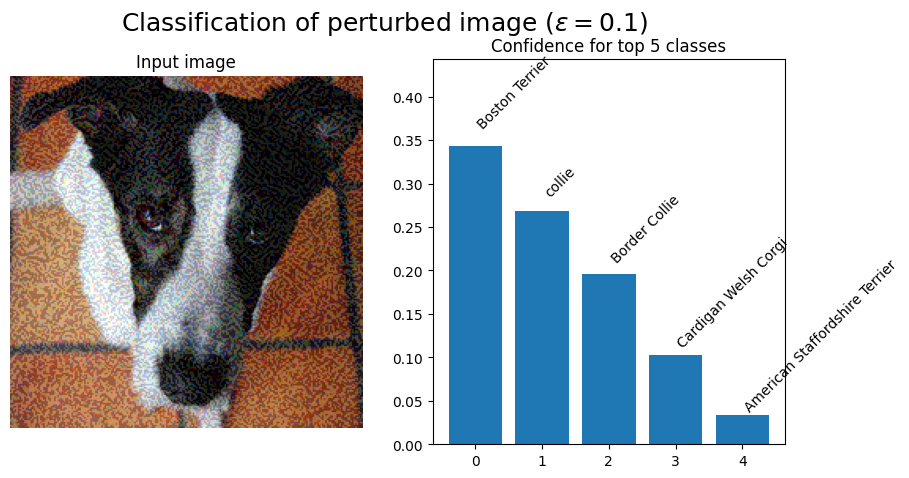

In [11]:
# perturb image of border collie
epsilon = 0.1
dog_perturbed = fgsm_perturb_img(dog_img, "Border Collie", model, epsilon)
y = model(dog_img)
plot_prediction(dog_img, y, title="Prediction on unperturbed image")
y = model(dog_perturbed)
plot_prediction(dog_perturbed, y, title=r"Classification of perturbed image ($\epsilon=$" + str(epsilon) + ")")

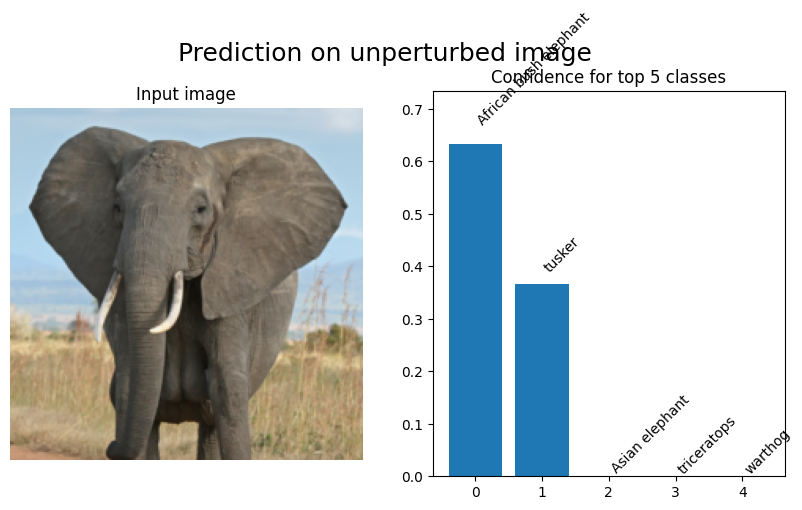

In [12]:
# open elephant image and visualize original prediction
elephant = Image.open("African_Bush_Elephant.jpg")
elephant = input_transform(elephant)
y = model(elephant)
plot_prediction(elephant, y, title="Prediction on unperturbed image")

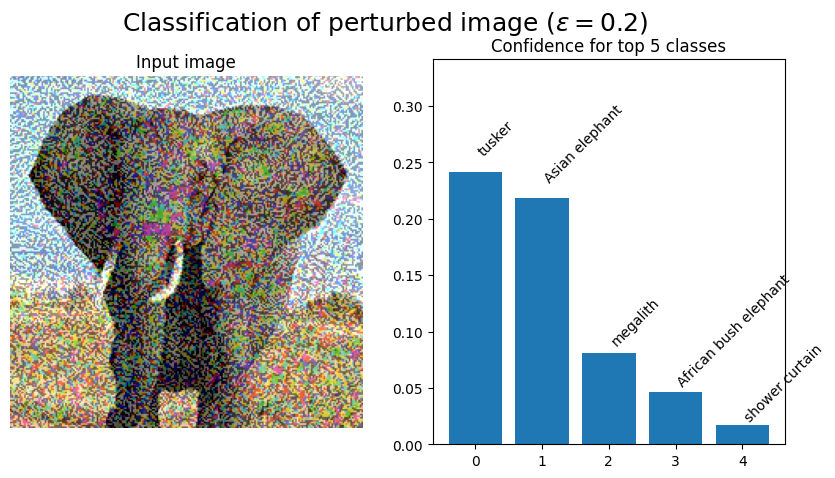

In [13]:
# perturb image of elephant and visualize prediction
epsilon = 0.2
elephant_perturbed = fgsm_perturb_img(elephant, "African bush elephant", model, epsilon)
y = model(elephant_perturbed)
plot_prediction(elephant_perturbed, y, title=r"Classification of perturbed image ($\epsilon=$" + str(epsilon) + ")")

## 2.3 Visualizing the Difference between the Original Image and the Perturbed Image
Implement the function  **`visualize_difference`** that takes in two images—the original image and the perturbed version of it—and visually compares them by calculating and displaying the absolute difference between the two images.

The function should:

1. Calculate the absolute difference between the two images.
2. Normalize the difference so that it can be visualized properly.
3. Display the original image, the perturbed image, and the difference side by side.

In [14]:
def visualize_difference(og_img, pert_img):
    """
    Visualizes the absolute difference between an original and a perturbed image.
    
    Parameters:
    og_img (PIL.Image.Image): The original image.
    pert_img (PIL.Image.Image): The perturbed image.

    Returns:
    None. Displays the original, perturbed, and difference images side by side.
    """

    # 1. Convert PIL images to NumPy arrays
    # We convert to float32 to ensure proper calculations
    og_array = np.array(og_img, dtype=np.float32)
    pert_array = np.array(pert_img, dtype=np.float32)

    # 2. Calculate the absolute difference
    # This subtraction is element-wise.
    diff_array = np.abs(og_array - pert_array)

    # 3. Normalize the difference image for visualization
    # We scale it to [0, 255] and convert to uint8 so imshow
    # displays it as a standard image (not a heatmap).
    # We clip to ensure values are valid, just in case.
    # Note: A common alternative is to just divide by diff_array.max()
    # but this can make subtle differences invisible.
    # Scaling to 0-255 is a common, understandable visualization.

    # Let's use a simpler normalization: scale to [0, 1]
    # This is better for imshow with floats.
    # We add a small epsilon to avoid division by zero if images are identical.
    diff_normalized = diff_array / (diff_array.max() + 1e-6)
    diff_normalized = np.clip(diff_normalized, 0, 1)


    # 4. Set up the plot
    # Create a figure with 1 row and 3 columns
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # 5. Display the Original Image
    axes[0].imshow(og_img) # imshow can handle PIL images directly
    axes[0].set_title("Original Image")
    axes[0].axis('off') # Hide axes ticks

    # 6. Display the Perturbed Image
    axes[1].imshow(pert_img)
    axes[1].set_title("Perturbed Image")
    axes[1].axis('off')

    # 7. Display the Difference Image
    # We use the normalized float array for the difference
    axes[2].imshow(diff_normalized)
    axes[2].set_title("Amplified Difference")
    axes[2].axis('off')

    # 8. Show the plot
    plt.tight_layout()
    plt.show()

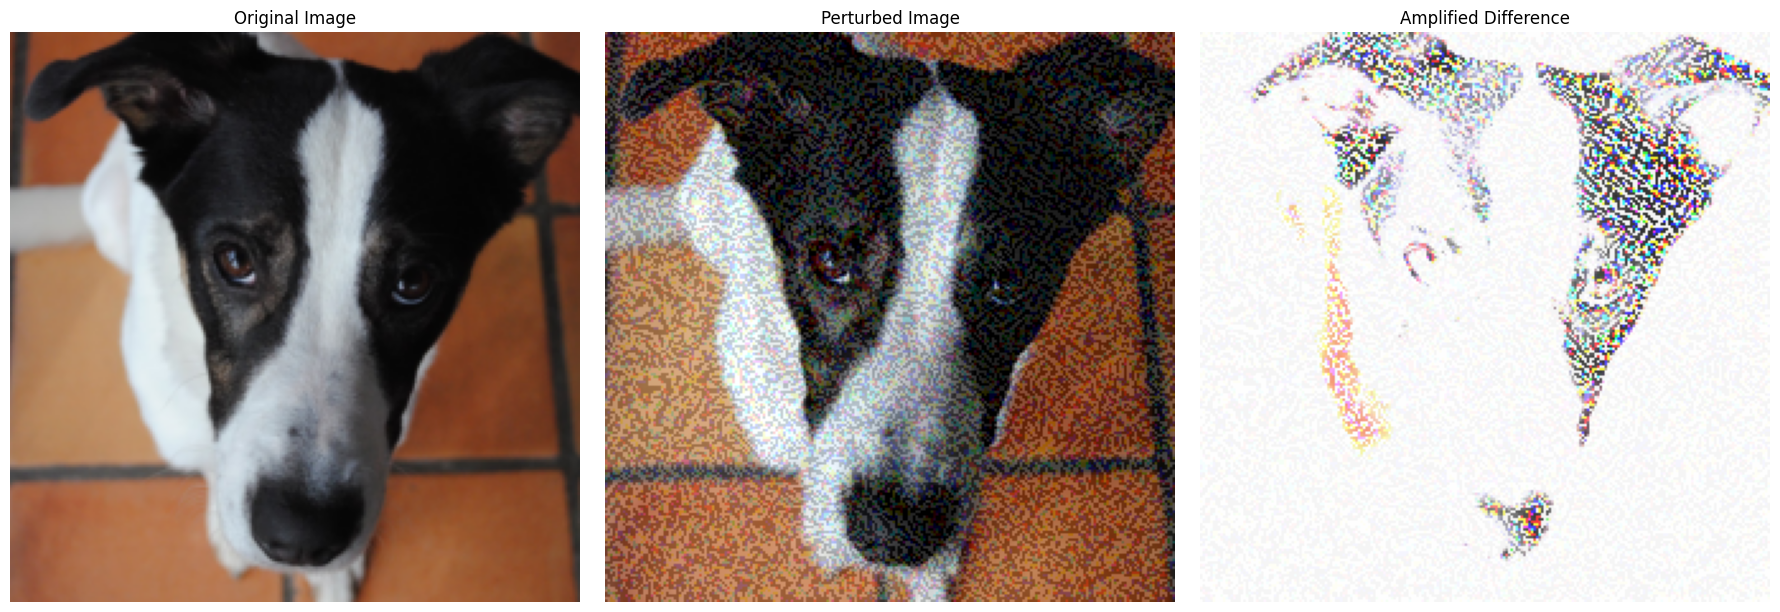

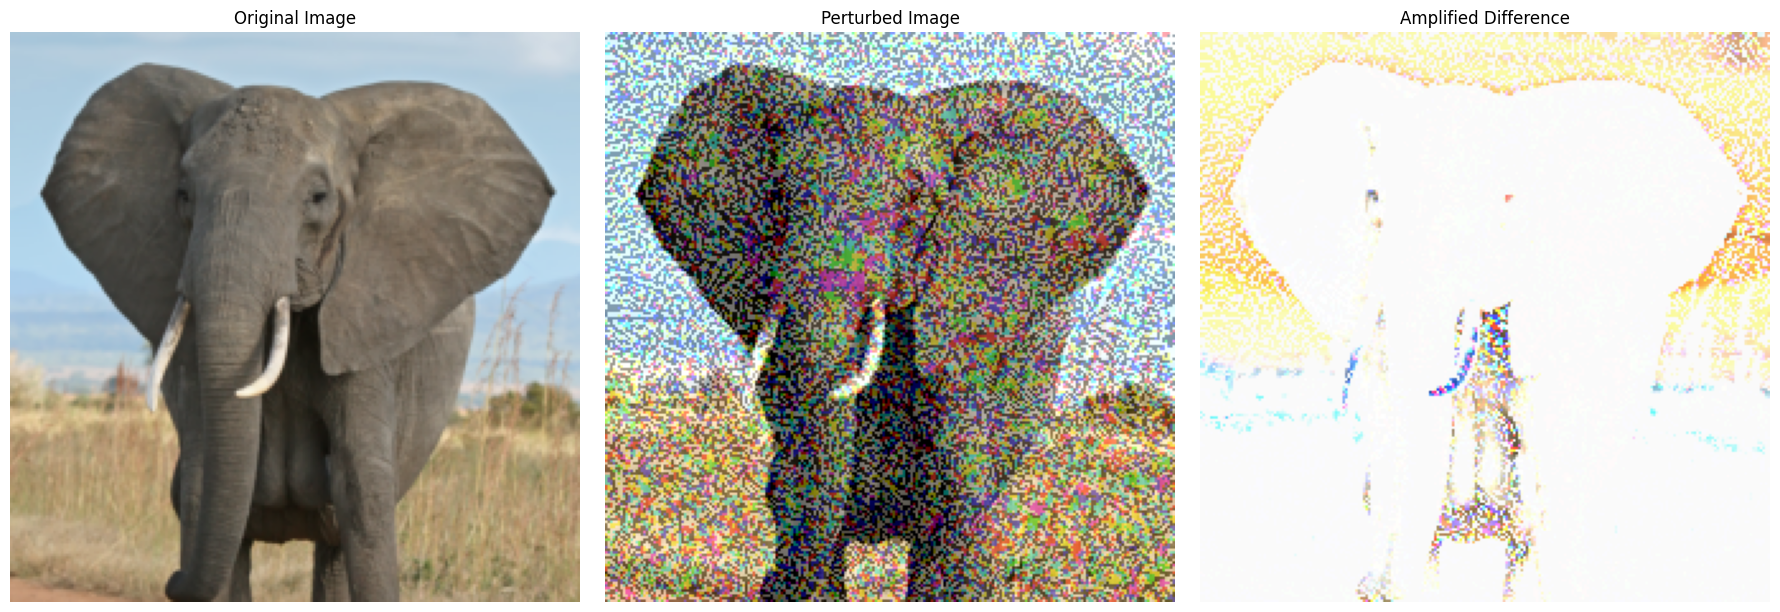

In [15]:
# compare elephant images
visualize_difference(dog_img, dog_perturbed)
# compare dog images
visualize_difference(elephant, elephant_perturbed)

### 2.4 Comparison to adding random noise
Implement the function **`add_random_noise`** that adds random noise to an image scaled by epsilon.  

1. Convert the image to a tensor using to_tensor(image).
2. Generate noise using torch.normal()
3. Add noise to the original image, scaled by epsilon.
4. Clamp pixel values between 0 and 1 to keep the result valid.

In [16]:
def add_random_noise(image, epsilon):
    """
    Adds random noise to an image with a given magnitude (epsilon).

    Parameters:
    image: The input image (e.g., a PIL image or similar) to which noise will be added.
    epsilon: The magnitude of the noise.

    Returns:
    A tensor of the image with random noise added, clamped between 0 and 1.
    """

    # (This function assumes 'import torch' and
    # 'import torchvision.transforms as transforms' were run outside the function)

    # 1. Define the transform to convert a PIL image to a [0, 1] tensor
    to_tensor = transforms.ToTensor()

    # 2. Convert the input image to a tensor
    # This tensor will have shape [C, H, W] and values in the [0, 1] range.
    img_tensor = to_tensor(image)

    # 3. Generate random noise
    # We create noise with the same shape as the image tensor.
    # torch.rand_like(img_tensor) creates values in [0, 1].
    # Multiplying by 2 and subtracting 1 scales this to the range [-1, 1].
    noise_unit_scale = (torch.rand_like(img_tensor) * 2) - 1

    # 4. Scale the noise by the epsilon parameter
    # The noise is now in the range [-epsilon, +epsilon]
    noise = noise_unit_scale * epsilon

    # 5. Add the noise to the original image tensor
    perturbed_image = img_tensor + noise

    # 6. Clamp the resulting image to the valid [0, 1] range
    # This ensures pixel values don't go below 0 or above 1.
    clamped_image = torch.clamp(perturbed_image, 0, 1)

    # 7. Return the final tensor
    return clamped_image

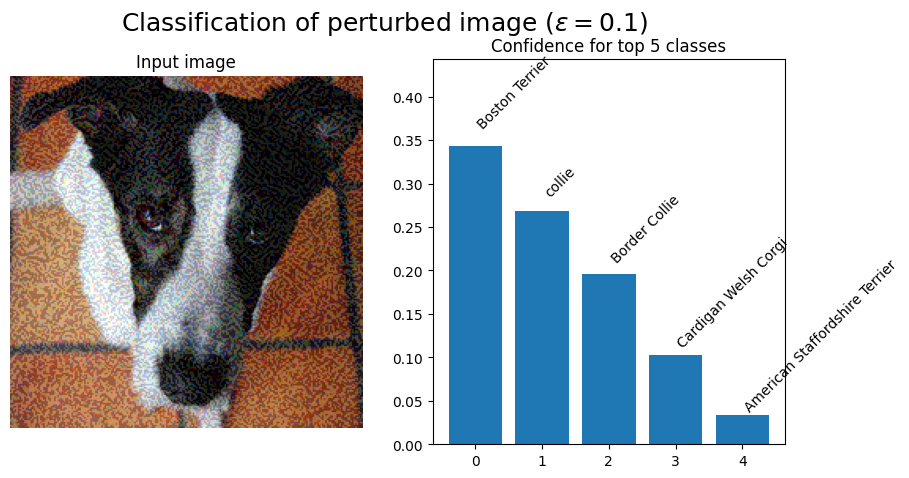

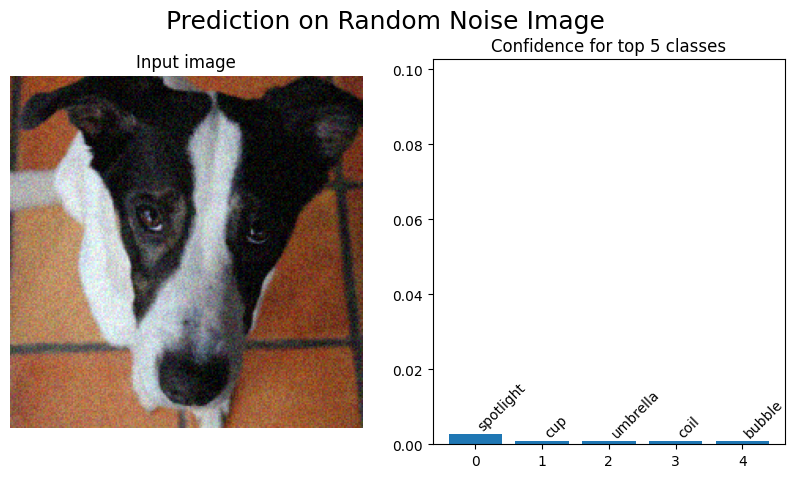

In [17]:
# generate noisy image with epsilon that tricks model using fgsm and plot prediction 
# compare to perturbed images with fgsm
# perturb image of border collie
epsilon = 0.1
dog_perturbed = fgsm_perturb_img(dog_img, "Border Collie", model, epsilon)
y = model(dog_perturbed)
plot_prediction(dog_perturbed, y, title=r"Classification of perturbed image ($\epsilon=$" + str(epsilon) + ")")

# --- 2. Create the Noisy Tensor ---
# This returns a [C, H, W] tensor with values in [0, 1]
noisy_tensor = add_random_noise(dog_img, epsilon)

# --- 3. Convert Noisy Tensor BACK to PIL Image (THE FIX) ---
# This is the step you were missing.
to_pil = transforms.ToPILImage()
noisy_pil_image = to_pil(noisy_tensor.cpu())

# --- 4. Get Model Prediction for the Noisy Image ---
# We must feed the TENSOR to the model, not the PIL image.

# 4a. Define the normalization (model expects this)
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

# 4b. Add batch dimension and normalize the tensor
# .unsqueeze(0) adds the batch dimension -> [1, C, H, W]
input_for_model = normalize(noisy_tensor.unsqueeze(0))

# 4c. Get the model's output
model.eval() # Set model to evaluation mode
device = next(model.parameters()).device # Get model's device
with torch.no_grad(): # No need to track gradients
    output_probs = model(input_for_model.to(device))

    # Apply softmax to get probabilities (your plot function likely needs this)
    output_probs = torch.nn.functional.softmax(output_probs, dim=1)


# --- 5. Call the Plot Function ---
# Now we have what plot_prediction expects:
# x = noisy_pil_image (a PIL Image)
# y = output_probs (a [1, 1000] tensor of probabilities)
plot_prediction(x=noisy_pil_image,
                y=output_probs,
                title="Prediction on Random Noise Image")

In [ ]:
def g(w):
    x = 0.5 * (torch.tanh(input=w) + 1)
    return x

def g_inverted(x):
    x_clamped = torch.clamp(x, min=1e-6, max=1-1e-6)
    w = torch.atanh(2 * x_clamped - 1)
    return w

def carlini_wagner_pertub_img(input_img, label, model, c=1.0, kappa=0.01, max_iterations=300, learning_rate=0.001):
    """
    Performs the Carlini & Wagner L2 adversarial attack.

    Args:
        input_img: The original image tensor x (values in [0, 1]).
        label: The target class index 't' we want the model to predict.
        model: The neural network Z(.) (must output raw logits).
        c: Trade-off constant between L2 distance and attack success.
        kappa: Confidence margin parameter.
        max_iterations: Number of optimization steps.
        learning_rate: Learning rate for the Adam optimizer.
    """

    w = g_inverted(x=input_img).detach().requires_grad(true) # init w and prepare for training
    optimizer = torch.optim.Adam([w], lr=learning_rate)
    for step in range(max_iterations):
        optimizer.zero_grad()

        # Forward pass through g(w) to get the adversarial image
        x_adv = g(w)

        # Term 1: L2 Distance ||g(w) - x||^2 -> Sum of squared error over all pixels
        l2_loss = torch.sum((x_adv - input_img) ** 2)

        # Term 2: The Attack Loss function f -> get logits Z(x_adv) from the model
        logits = model(x_adv)
        target_logit = logits[0, label] # Z(g(w))_t is the logit of the target class (label)
        # We need max_{i != t} Z(g(w))_i (the highest logit among non-target classes)
        # We clone logits and set the target index to -infinity so it isn't picked as max
        logits_without_target = logits.clone()
        logits_without_target[0, label] = -float('inf')
        max_other_logit = torch.max(logits_without_target)
        difference = max_other_logit - target_logit # Calculate difference: max_others - target
        # Apply the margin kappa using the formula: max(-kappa, difference)
        # This is the hinge loss variant specific to C&W
        kappa_tensor = torch.tensor(-kappa, device=input_img.device, dtype=input_img.dtype)
        attack_loss = torch.max(kappa_tensor, difference)

        # combine for total objective
        total_loss = l2_loss + c * attack_loss

        # Backpropagation
        total_loss.backward()
        optimizer.step()

    # Return the final adversarial image detached from the graph
    final_adv_img = 0.5 * (torch.tanh(w) + 1)
    return final_adv_img.detach()